In [7]:
import matplotlib.pyplot as plt
import matplotlib.mlab as mlab
%matplotlib inline
from __future__ import division 
import numpy as np
from numpy import linalg as LA
from scipy import linalg
from scipy import stats
from pylab import * 
import math
#from pylab import rcParams
#from tempfile import TemporaryFile
P = open("/cueva/Susana/Susana_josePC/Prices.txt","rb")
S = open("/cueva/Susana/Susana_josePC/Symbols.txt","r")
D = open("/cueva/Susana/Susana_josePC/Dates.txt","r")
G = open("/cueva/Susana/Susana_josePC/Gics.txt","r")
from matplotlib.lines import Line2D

In [2]:
cwoe=np.load("/cueva/Susana/SusanaDos/CWOEevalores/CWOEvalor2q1.05.npy")
cwoe2=np.load("/cueva/Susana/SusanaDos/CWOEevalores/CWOEcte3q1.05.npy")
cwoesec=np.load("/cueva/Susana/SusanaDos/CWOEevalores/CWOEsector2q1.05.npy")
cwoesec2=np.load("/cueva/Susana/SusanaDos/CWOEevalores/CWOEsector3q1.05.npy")
woe=np.load("/cueva/Susana/SusanaDos/CWOEevalores/WOEq1.05.npy")
cwoenosec=np.load("/cueva/Susana/SusanaDos/CWOEevalores/CWOEnosector2q1.05.npy")

In [3]:
def remove_cruft(s):
    return s[:-6]

In [5]:
def map_level(f, item, level):
    if level == 0:
        return f(item)
    else:
        return [map_level(f, i, level - 1) for i in item]

In [8]:
s=[]
lines=S.readlines()
S.close()
for line in lines:
	values = line.split()
	s.append(values[0])
lensymbols=len(s)

d=[]
lines=D.readlines()
D.close() 
for line in lines:
	values = line.split()
	d.append(values[0])
#print type(values)	
lendates=len(d)

g=[]
lines=G.readlines()
G.close()
for line in lines:
	values = line.split()
	g.append(values[0])
    
Prices=np.loadtxt("Prices.txt")      
lenPrices=len(Prices)

In [9]:
#----- Rendimientos---

Returns=[]

for i in range(lensymbols):
	Returns.append([])
	for j in range(1,lendates):
		r=(Prices[i][j-1]/Prices[i][j])-1
                Returns[-1].append(r)
Returns=np.asarray(Returns)
#print len(Returns)

In [9]:
qs=[.05,.1,.15,.2,.5]

In [10]:
gicname=[]
gicname=g[:]
for i in xrange(293):
    gicname[i]=gicname[i].replace("10","E")
    gicname[i]=gicname[i].replace("15","M")
    gicname[i]=gicname[i].replace("20","I")
    gicname[i]=gicname[i].replace("25","CD")
    gicname[i]=gicname[i].replace("30","CS")
    gicname[i]=gicname[i].replace("35","HC")
    gicname[i]=gicname[i].replace("40","F")
    gicname[i]=gicname[i].replace("45","IT")
    gicname[i]=gicname[i].replace("50","TS")
    gicname[i]=gicname[i].replace("55","U")
    gicname[i]=gicname[i].replace("60","RE")

In [11]:
import collections, numpy
collections.Counter(gicname)

Counter({'CD': 46,
         'CS': 26,
         'E': 23,
         'F': 47,
         'HC': 29,
         'I': 39,
         'IT': 33,
         'M': 21,
         'TS': 5,
         'U': 24})

In [19]:
anios=[]
an=1992
for i in xrange(23):
    an=1992+i
    anios.append(an)
len(anios)

23

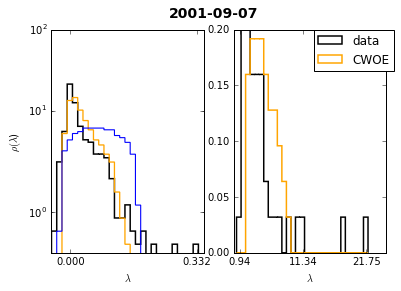

In [25]:
i=110
fecha=d[(i*22)]
N=293        
ww=np.loadtxt("/cueva/Susana/SusanaDos/evaluesyevectosQs/evalorPM%dq1.05.dat"%i)
T=44
binlim = np.linspace(-.05,.35,30)
binlim1 = np.linspace(.4,22,30)
fig, (ax2, ax) = plt.subplots(1, 2, sharey=False)
fig.suptitle('%s'%fecha, fontsize=14, fontweight='bold')
ax.set_xlabel(r"$\lambda$")
ax2.set_xlabel(r"$\lambda$")
ax2.set_ylabel(r"$\rho(\lambda$)")
nomb=r"$\lambda_{max}=$"+str(round(np.max(ww),3))
ax.hist(ww[250:292], binlim1, color = "black",label="data", normed=T-1, histtype='step',linewidth=1.5)
#ax.hist(cwoenosec[i][250:292], binlim1,color="blue", label="CWOE sectores", normed=1, histtype='step',linewidth=1.4)
ax.hist(cwoe[i][250:292], binlim1 ,color="orange",label="CWOE", normed=1, histtype='step',linewidth=1.5)
#ax.hist(woe[250:292], binlim1 ,color="b",label="WOE", normed=1, histtype='step',linewidth=1.1)
ax.legend(bbox_to_anchor=(1.05, 1), loc=1, borderaxespad=0.)
xmax=np.max(ww[250:292])
xmin=np.min(ww[250:292])
xmedio=0.5*(xmax+xmin)
ax.set_xticks([round(xmax,3),round(xmin,3),round(xmedio,3)])
#ax.text(3,0.6,r"$\lambda_{max}=$"+str(round(np.max(ww),3)),bbox={ 'facecolor':'white','alpha':0.5 })
ax2.hist(ww[:N-T+1], binlim, color = "black", normed=N-T+1, histtype='step',linewidth=1.5)
#ax2.hist(cwoenosec[i][:N-T+1], binlim ,color="blue", normed=N-T+1, histtype='step',linewidth=1.4)
ax2.hist(cwoe[i][:N-T+1], binlim ,color="orange", normed=N-T+1, histtype='step',linewidth=1.3)
ax2.hist(woe[:N-T+1], binlim ,color="b", normed=N-T+1, histtype='step',linewidth=1.1)
ax2.set_yscale('symlog')
xmax2=np.max(ww[:250])
xmin2=np.min(ww[:250])
xmedio=0.5*(xmax+xmin)
ax2.set_xticks([round(xmax2,3),0])
titulo="/cueva/Susana/SusanaDos/tesis_latex/espectrocompleto%d.pdf"%i
#plt.savefig(titulo, format='pdf', dpi=1000)

In [154]:
#eigenvalor mas grande de todas las fechas
evalor_max=[]
for i in xrange(0,262,2):
    ww=np.loadtxt("/cueva/Susana/SusanaDos/evaluesyevectosQs/evalorPM%dq1.05.dat"%i)
    evalor_max.append(np.max(ww))

In [71]:
#eigenvalor mayor y menor del espectro emergente
es_max=[]
es_min=[]
for i in xrange(0,262,2):
    ww=np.loadtxt("/cueva/Susana/SusanaDos/evaluesyevectosQs/evalorPM%dq1.05.dat"%i)
    es_min.append(ww[0])
    es_max.append(ww[249])

In [12]:
Cmean=[]
CPmean=[]
for i in range(262):
    #fecha=d[i]
    C=np.loadtxt("/cueva/Susana/SusanaDos/SYP-q1.05/MatrizCorr%d.dat"%i)
    #CP=np.loadtxt("/cueva/Susana/SusanaDos/SYP-q1.05/MatrizCorrPM%dq1.10.dat"%i)
    cm=C.sum()-N
    cm=cm/(N**2-N)
    Cmean.append(cm)
    #CPmean.append(cpm)

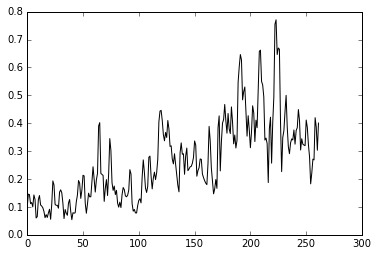

In [13]:
#grafica de eigenvalor menor y mayor del espectro emergente
#plt.plot(es_max)
plt.plot(Cmean,"black")
#plt.plot(evalor_max)

In [7]:
for i in xrange(131):
    if es_min[i]<-0.08:
        ee=i*2
        print i, es_min[i],d[i],ee

NameError: name 'es_min' is not defined

In [101]:
131/23

5.695652173913044

NameError: name 'evalor_max' is not defined

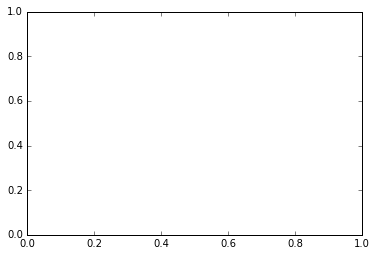

In [6]:
#grafica de evalor mayor
num=5.695
indice = np.arange(0,131,num)

fig, ax = plt.subplots()
plt.plot(evalor_max,linewidth=1.3)
#plt.plot(Cmean[::2], "b")
ax.spines['right'].set_visible(False)
ax.spines['top'].set_visible(False)
ax.yaxis.set_ticks_position('left')
ax.xaxis.set_ticks_position('bottom')
indice = np.arange(0,132,num)
#plt.xticks(indice[:],[remove_cruft(s) for s in fechalabel], rotation = 90)
plt.xticks(indice[:],anios, rotation = 90)
fecha=d[0::44]
#fechalabel=fecha[::num]
fechalabel=anios
#plt.xticks(indice,fechalabel, rotation = 90)
plt.ylabel("Largest eigenvalue")
dia2=fecha[111]
dia=fecha[113]
dia3=fecha[104]
#plt.annotate(dia, xy=(113, 195.750489062), xycoords='data',xytext=(50, -20), textcoords='offset points', arrowprops=dict(arrowstyle="->"))
#plt.annotate(dia2, xy=(111, 220.437607977), xycoords='data',xytext=(10, 10), textcoords='offset points', arrowprops=dict(arrowstyle="->"))
#plt.annotate(dia3, xy=(104, 193.48359513), xycoords='data',xytext=(-90, -0), textcoords='offset points', arrowprops=dict(arrowstyle="->"))
plt.grid(True)
plt.savefig('/cueva/Susana/SusanaDos/tesis_latex/valormayor.eps', format='eps', dpi=1000)

In [14]:
#Contando ceros 
sumzero=[]
for z in xrange(261):
        sumacero=0
        ww1=np.loadtxt("evalor%d.dat"%z)
        for j in ww1:
            if  j <= 1e-13:
                sumacero+=1
        sumzero.append(sumacero)
#print sumzero

In [15]:
#haciendo lista de los momentos para el espectro emergente
m1list=[]
m2list=[]
m3list=[]
m4list=[]
m5list=[]
m6list=[]
skwns=[]
kurtos=[]
N=293
T=44
for i in xrange(262):
    
      
    ww=np.loadtxt("/cueva/Susana/SusanaDos/evaluesyevectosQs/evalorPM%dq1.05.dat"%i)
    ske=stats.skew(ww[:N-T+1])
    krt=stats.kurtosis(ww[:N-T+1])
    m1=np.mean(ww[:N-T+1])
    wstd=np.std(ww[:N-T+1])
    m2=np.var(ww[:N-T+1])
    m3=(np.std(ww[:N-T+1]))**3
    m4=(np.std(ww[:N-T+1]))**4
    m5=(np.std(ww[:N-T+1]))**5
    m6=(np.std(ww[:N-T+1]))**6
    m1list.append(m1)
    m2list.append(m2)
    m3list.append(m3)
    m4list.append(m4)
    m5list.append(m5)
    m6list.append(m6)
    skwns.append(ske)
    kurtos.append(krt)

In [17]:
Cmean=np.asarray(Cmean)
skwns=np.asarray(skwns)
Cmean1=[(s-Cmean.mean())/Cmean.std() for s in Cmean]
skwns1=[(s-skwns.mean())/skwns.std() for s in skwns]

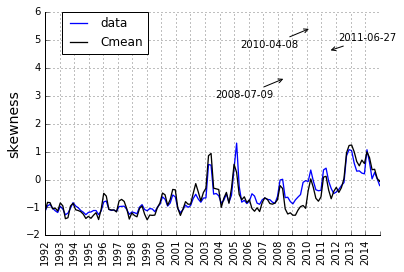

In [25]:
num=5.695
indice = np.arange(0,262,num)

fig, ax = plt.subplots()
plt.plot(skwns1,linewidth=1.3, label="data")
#plt.plot(m3nosec, "r", label="CWOE+sectores")
plt.plot(Cmean1, linewidth=1.3, color="black", label="Cmean")

fecha=d[0::44]
#fechalabel=fecha[::num]
plt.xticks(indice[:],anios, rotation = 90)
#plt.xticks(indice,[remove_cruft(s) for s in fechalabel], rotation = 90)
plt.ylabel("skewness",fontsize=14)
plt.legend(bbox_to_anchor=(.05, 1), loc=2, borderaxespad=0.)

#rcParams['figure.figsize'] = 35,5
plt.xlim(0,131)
dia2=fecha[104]
dia=fecha[111]
dia3=fecha[94]
plt.annotate(dia, xy=(111, 4.60707550716), xycoords='data',xytext=(10, 10), textcoords='offset points', arrowprops=dict(arrowstyle="->"))
plt.annotate(dia2, xy=(104, 5.42757043406), xycoords='data',xytext=(-70, -20), textcoords='offset points', arrowprops=dict(arrowstyle="->"))
plt.annotate(dia3, xy=(94, 3.63531562809), xycoords='data',xytext=(-70, -20), textcoords='offset points', arrowprops=dict(arrowstyle="->"))
#fig, ax = plt.subplots()
ax.spines['right'].set_visible(False)
ax.spines['top'].set_visible(False)
ax.yaxis.set_ticks_position('left')
ax.xaxis.set_ticks_position('bottom')
plt.grid(True)
#plt.savefig('/cueva/Susana/SusanaDos/tesis_latex/skewness.eps', format='eps', dpi=1000)

In [115]:
for i in xrange(131):
    if kurtos[i]>20:
        print i, kurtos[i]

94 23.4503851988
104 35.8971269786
111 27.4465365358
112 22.924173058
113 26.6543218597


In [120]:
for i in xrange(131):
    if skwns[i]>3.4:
        print i, skwns[i]    


94 3.63531562809
97 3.49358664429
104 5.42757043406
105 3.96040733153
111 4.60707550716
112 4.29732669529
113 4.49220696097


NameError: name 'skwns' is not defined

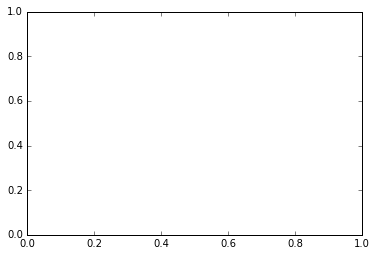

In [35]:
num=5.695
indice = np.arange(0,131,num)

fig, ax = plt.subplots()
plt.plot(skwns,linewidth=1.5, label="data")
#plt.plot(m3nosec, "r", label="CWOE+sectores")
#plt.plot(m3, "black", label="CWOE")
plt.plot(Cmean[::2])
indice = np.arange(0,132,num)
fecha=d[0::44]
#fechalabel=fecha[::num]
plt.xticks(indice[:],anios, rotation = 90)
#plt.xticks(indice,[remove_cruft(s) for s in fechalabel], rotation = 90)
plt.ylabel("skewness",fontsize=14)
plt.legend(bbox_to_anchor=(.05, 1), loc=2, borderaxespad=0.)

#rcParams['figure.figsize'] = 35,5
plt.xlim(0,131)
dia2=fecha[104]
dia=fecha[111]
dia3=fecha[94]
plt.annotate(dia, xy=(111, 4.60707550716), xycoords='data',xytext=(10, 10), textcoords='offset points', arrowprops=dict(arrowstyle="->"))
plt.annotate(dia2, xy=(104, 5.42757043406), xycoords='data',xytext=(-70, -20), textcoords='offset points', arrowprops=dict(arrowstyle="->"))
plt.annotate(dia3, xy=(94, 3.63531562809), xycoords='data',xytext=(-70, -20), textcoords='offset points', arrowprops=dict(arrowstyle="->"))
#fig, ax = plt.subplots()
ax.spines['right'].set_visible(False)
ax.spines['top'].set_visible(False)
ax.yaxis.set_ticks_position('left')
ax.xaxis.set_ticks_position('bottom')
plt.grid(True)
plt.savefig('/cueva/Susana/SusanaDos/tesis_latex/skewness.eps', format='eps', dpi=1000)


In [33]:
#calculando los momentos para CWOE

m1=[]
m2=[]
m3=[]
m4=[]
for i in xrange(0,262,2):
    mo1=np.mean(cwoe[i][:N-T+1])
    mo2=np.var(cwoe[i][:N-T+1])
    mo3=(np.std(cwoe[i][:N-T+1]))**3
    mo4=(np.std(cwoe[i][:N-T+1]))**4
    ske=stats.skew(cwoe[i][:N-T+1])
    krt=stats.kurtosis(cwoe[i][:N-T+1])
    m1.append(mo1)
    m2.append(mo2)
    m3.append(ske)
    m4.append(krt)

In [34]:
#calculando los momentos para CWOE

mnew1=[]
mnew2=[]
mnew3=[]
mnew4=[]
for i in xrange(0,262,2):
    mo1=np.mean(cwoe2[i][:N-T+1])
    mo2=np.var(cwoe2[i][:N-T+1])
    mo3=(np.std(cwoe2[i][:N-T+1]))**3
    mo4=(np.std(cwoe2[i][:N-T+1]))**4
    ske=stats.skew(cwoe2[i][:N-T+1])
    krt=stats.kurtosis(cwoe2[i][:N-T+1])
    mnew1.append(mo1)
    mnew2.append(mo2)
    mnew3.append(ske)
    mnew4.append(krt)

In [21]:
#calculando los momentos para CWOE

m1sec2=[]
m2sec2=[]
m3sec2=[]
m4sec2=[]
for i in xrange(0,262,2):
    mo1=np.mean(cwoesec2[i][:N-T+1])
    mo2=np.var(cwoesec2[i][:N-T+1])
    mo3=(np.std(cwoesec2[i][:N-T+1]))**3
    mo4=(np.std(cwoesec2[i][:N-T+1]))**4
    ske=stats.skew(cwoesec2[i][:N-T+1])
    krt=stats.kurtosis(cwoesec2[i][:N-T+1])
    
    m1sec2.append(mo1)
    m2sec2.append(mo2)
    m3sec2.append(ske)
    m4sec2.append(krt)

In [22]:
#calculando los momentos para CWOE

m1sec=[]
m2sec=[]
m3sec=[]
m4sec=[]
for i in xrange(0,262,2):
    mo1=np.mean(cwoesec[i][:N-T+1])
    mo2=np.var(cwoesec[i][:N-T+1])
    mo3=(np.std(cwoesec[i][:N-T+1]))**3
    mo4=(np.std(cwoesec[i][:N-T+1]))**4
    ske=stats.skew(cwoesec[i][:N-T+1])
    krt=stats.kurtosis(cwoesec[i][:N-T+1])
    m1sec.append(mo1)
    m2sec.append(mo2)
    m3sec.append(ske)
    m4sec.append(krt)

In [23]:
#calculando los momentos para CWOE

m1nosec=[]
m2nosec=[]
m3nosec=[]
m4nosec=[]

for i in xrange(0,262,2):
    mo1=np.mean(cwoenosec[i][:N-T+1])
    mo2=np.var(cwoenosec[i][:N-T+1])
    mo3=(np.std(cwoenosec[i][:N-T+1]))**3
    mo4=(np.std(cwoenosec[i][:N-T+1]))**4
    ske=stats.skew(cwoenosec[i][:N-T+1])
    krt=stats.kurtosis(cwoenosec[i][:N-T+1])
    m1nosec.append(mo1)
    m2nosec.append(mo2)
    m3nosec.append(ske)
    m4nosec.append(krt)

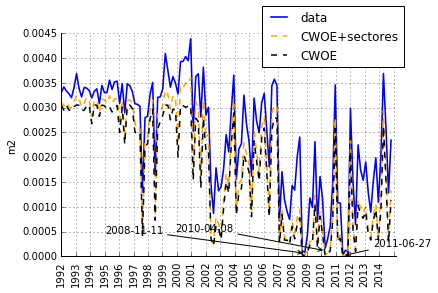

In [113]:
#grafica segundo momento
num=5.695
indice = np.arange(0,131,num)

fig, ax = plt.subplots()
plt.plot(m2list, linewidth=1.6, alpha=1, label="data");
#plt.plot(m2sec,"--",color="purple",linewidth=1.5)
#plt.plot(mnew2,"--",color="red",linewidth=1.5)
plt.plot(m2nosec,"--",color="orange",linewidth=1.5, label="CWOE+sectores")
plt.plot(m2,"--",color="black",linewidth=1.5, label="CWOE");
plt.legend(bbox_to_anchor=(.6, 1.12), loc=2, borderaxespad=0.)
#dia=fecha[111]
plt.xticks(indice[:],anios, rotation = 90)
fecha=d[0::44]
dia=fecha[111]
#fechalabel=fecha[::num]
#plt.xticks(indice[:],[remove_cruft(s) for s in fechalabel], rotation = 90)
#plt.ylabel(r"$\sigma^2$",fontsize=18)
plt.ylabel("m2")
plt.xlim(0,132)
dia2=fecha[104]
dia3=fecha[111]
dia=fecha[96]
plt.annotate(dia, xy=(96,6.15292789132e-05), xycoords='data',xytext=(-200, 20), textcoords='offset points', arrowprops=dict(arrowstyle="->"))
plt.annotate(dia2, xy=(104,0.000113709897244), xycoords='data',xytext=(-150, 20), textcoords='offset points', arrowprops=dict(arrowstyle="->"))
plt.annotate(dia3, xy=(111, 1.34858757402e-05), xycoords='data',xytext=(30, 10), textcoords='offset points', arrowprops=dict(arrowstyle="->"))
#rcParams['figure.figsize'] = 35,5
#fig, ax = plt.subplots()
ax.spines['right'].set_visible(False)
ax.spines['top'].set_visible(False)
ax.yaxis.set_ticks_position('left')
ax.xaxis.set_ticks_position('bottom')
plt.grid()
plt.savefig('/cueva/Susana/SusanaDos/tesis_latex/m2.eps', format='eps', dpi=1000)


5.954545454545454

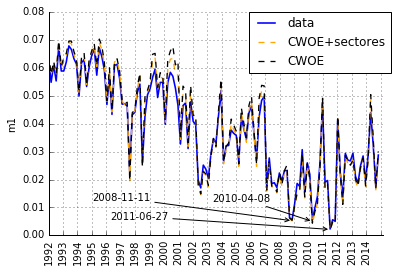

In [115]:
num=5.695
indice = np.arange(0,131,num)

fig, ax = plt.subplots()
plt.plot(m1list, linewidth=1.6, alpha=1, label="data")
#plt.plot(m1sec,"--",color="purple", linewidth=1.3)
plt.plot(m1nosec,"--",color="orange", linewidth=1.3, label="CWOE+sectores")
plt.plot(m1,"--",color="black", linewidth=1.3, label="CWOE")
plt.legend(bbox_to_anchor=(.6, 1), loc=2, borderaxespad=0.)
indice = np.arange(0,132,num)
fecha=d[0::44]
plt.xticks(indice[:],anios, rotation = 90)
#fechalabel=fecha[::num]
#plt.xticks(indice[:],[remove_cruft(s) for s in fechalabel], rotation = 90)
plt.ylabel("m1")
plt.xlim(0,132)
dia2=fecha[104]
dia=fecha[111]
dia3=fecha[96]
plt.annotate(dia, xy=(111, 0.00210605584295), xycoords='data',xytext=(-220, 10), textcoords='offset points', arrowprops=dict(arrowstyle="->"))
#plt.annotate(dia, xy=(113, 0.00466202613467), xycoords='data',xytext=(10, 20), textcoords='offset points', arrowprops=dict(arrowstyle="->"))
plt.annotate(dia2, xy=(104, 0.00497680137287), xycoords='data',xytext=(-100, 20), textcoords='offset points', arrowprops=dict(arrowstyle="->"))
plt.annotate(dia3, xy=(96, 0.0052104649901), xycoords='data',xytext=(-200, 20), textcoords='offset points', arrowprops=dict(arrowstyle="->"))
#plt.annotate(dia, xy=(112, 0.0052423578427), xycoords='data',xytext=(-40, 20), textcoords='offset points', arrowprops=dict(arrowstyle="->"))

#fig, ax = plt.subplots()
ax.spines['right'].set_visible(False)
ax.spines['top'].set_visible(False)
ax.yaxis.set_ticks_position('left')
ax.xaxis.set_ticks_position('bottom')
plt.grid()
plt.savefig('/cueva/Susana/SusanaDos/tesis_latex/mean.eps', format='eps', dpi=1000)

In [51]:
for i in xrange(131):
    if m2list[i]<0.0002:
        print i, m2list


95 9.11445682007e-05
96 6.15292789132e-05
104 0.000113709897244
111 1.34858757402e-05
112 9.48479096148e-05
113 7.19226703198e-05


In [7]:
#haciendo grafica de los moments
num=10
plt.plot(m1list,label="q=1.05")
#plt.plot(m1list1,label="q=1.10")
#plt.plot(m1list15,label="q=1.15")
plt.legend()
indice = np.arange(0,132,num)
fecha=d[0::44]
fechalabel=fecha[::num]
plt.xticks(indice,fechalabel, rotation = 30)
plt.ylabel("mean",fontsize=14)
titulo="/cueva/Susana/SusanaDos/figHisto/m1es.png" 
savefig(titulo, bbox_inches='tight')

plt.clf()
plt.close()
plt.plot(m2list,label="q=1.05")
#plt.plot(m2list1,label="q=1.10")
#plt.plot(m2list15,label="q=1.15")
plt.legend()
plt.ylabel(r"$\sigma^2$",fontsize=14)
plt.xticks(indice,fechalabel, rotation = 30)
titulo="/cueva/Susana/SusanaDos/figHisto/m2es.png" 
savefig(titulo, bbox_inches='tight')
plt.clf()
plt.close()
plt.plot(m3list,label="q=1.05")
#plt.plot(m3list1,label="q=1.10")
#plt.plot(m3list15,label="q=1.15")
plt.legend()
plt.ylabel(r"$\sigma^3$",fontsize=14)
plt.xticks(indice,fechalabel, rotation = 30)
titulo="/cueva/Susana/SusanaDos/figHisto/m3es.png" 
savefig(titulo, bbox_inches='tight')
plt.clf()
plt.close()
plt.plot(m4list,label="q=1.05")
#plt.plot(m4list1,label="q=1.10")
#plt.plot(m4list15,label="q=1.15")
plt.legend()
plt.ylabel(r"$\sigma^4$",fontsize=14)
plt.xticks(indice,fechalabel, rotation = 30)
titulo="/cueva/Susana/SusanaDos/figHisto/m4s.png" 
savefig(titulo, bbox_inches='tight')
plt.clf()
plt.close()
plt.plot(m5list,label="q=1.05")
#plt.plot(m5list1,label="q=1.10")
#plt.plot(m5list15,label="q=1.15")
plt.legend()
plt.xticks(indice,fechalabel, rotation = 30)
plt.ylabel(r"$\sigma^5$",fontsize=14)
titulo="/cueva/Susana/SusanaDos/figHisto/m5es.png" 
savefig(titulo, bbox_inches='tight')
plt.clf()
plt.close()
plt.plot(m6list,label="q=1.05")
#plt.plot(m6list1,label="q=1.10")
#plt.plot(m6list15,label="q=1.15")
plt.legend()
plt.xticks(indice,fechalabel, rotation = 30)
plt.ylabel(r"$\sigma^6$",fontsize=14)
titulo="/cueva/Susana/SusanaDos/figHisto/m6es.png" 
savefig(titulo, bbox_inches='tight')
plt.clf()
plt.close()

In [38]:
dias=10
shift=10
N=293
T=dias
lenret=len(Returns)
nummat=(len(Returns[0])-shift)/shift
neganum50=[]
neganum=[]
qs=[.0005,.0010,.0050,.0100,.0200,.0500]
for e in qs:
    q=1+e
    for i in xrange(int(nummat)-2):
        suma=0
        
        ww=np.load("/cueva/Susana/PaperPM/Values1/evalorPM%dq%.4fT%d.npy"%(i,q,dias))
        for valor in ww[:N-T+1]:
            if valor< -1e-16:
                suma+=1
            #print suma
        neganum.append(suma)
    neganum50.append(neganum)
    neganum=[]

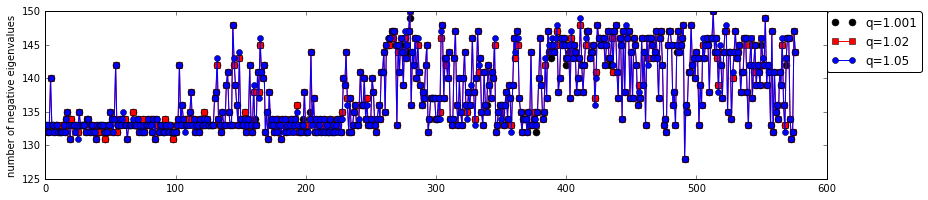

In [39]:
rcParams['figure.figsize'] = 14, 3
#plt.plot(neganum0005,"-*",label="q=1.0005",color="orange")
plt.plot(neganum50[1],"o",markersize=7,color="black", label="q=1.001")
#plt.plot(neganum0050,"-s",markersize=6,color="black", label="q=1.005")
plt.plot(neganum50[3],"-s",markersize=6,color="red", label="q=1.02")
plt.plot(neganum50[5],"-o",markersize=6, color="blue", label="q=1.05")
#plt.xlim(0,262)
plt.ylabel("number of negative eigenvalues")
plt.legend(bbox_to_anchor=(1, 1), loc=2, borderaxespad=0., fancybox=True)

In [40]:
dias=30
shift=15
N=293
T=dias
lenret=len(Returns)
nummat=(len(Returns[0])-shift)/shift
neganum50=[]
neganum=[]
qs=[.0005,.0010,.0050,.0100,.0200,.0500]
for e in qs:
    q=1+e
    for i in xrange(int(nummat)):
        suma=0
        
        ww=np.loadtxt("/cueva/Susana/PaperPM/Values/evalorPM%dq%.4fT%d.dat"%(i,q,dias))
        for valor in ww[:N-T+1]:
            if valor< -1e-16:
                suma+=1
            #print suma
        neganum.append(suma)
    neganum50.append(neganum)
    neganum=[]

In [115]:
len(neganum50[2])

386

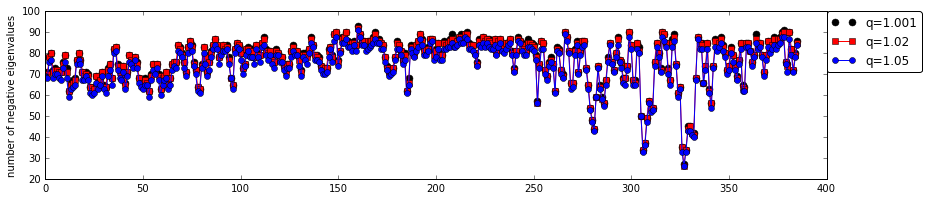

In [116]:
rcParams['figure.figsize'] = 14, 3
#plt.plot(neganum0005,"-*",label="q=1.0005",color="orange")
plt.plot(neganum50[1],"o",markersize=7,color="black", label="q=1.001")
#plt.plot(neganum0050,"-s",markersize=6,color="black", label="q=1.005")
plt.plot(neganum50[3],"-s",markersize=6,color="red", label="q=1.02")
plt.plot(neganum50[5],"-o",markersize=6, color="blue", label="q=1.05")
#plt.xlim(0,262)
plt.ylabel("number of negative eigenvalues")
plt.legend(bbox_to_anchor=(1, 1), loc=2, borderaxespad=0., fancybox=True)

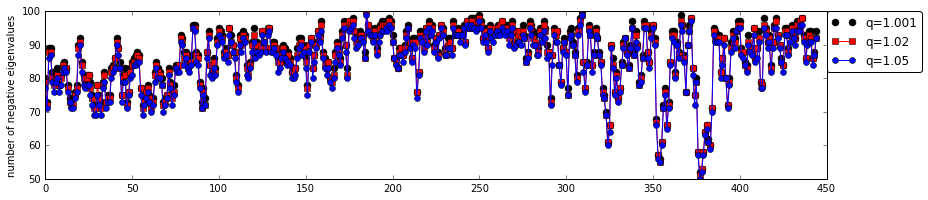

In [29]:
rcParams['figure.figsize'] = 14, 3
#plt.plot(neganum0005,"-*",label="q=1.0005",color="orange")
plt.plot(neganum0010,"o",markersize=7,color="black", label="q=1.001")
#plt.plot(neganum0050,"-s",markersize=6,color="black", label="q=1.005")
plt.plot(neganum0200,"-s",markersize=6,color="red", label="q=1.02")
plt.plot(neganum0500,"-o",markersize=6, color="blue", label="q=1.05")
#plt.xlim(0,262)
plt.ylabel("number of negative eigenvalues")
plt.legend(bbox_to_anchor=(1, 1), loc=2, borderaxespad=0., fancybox=True)

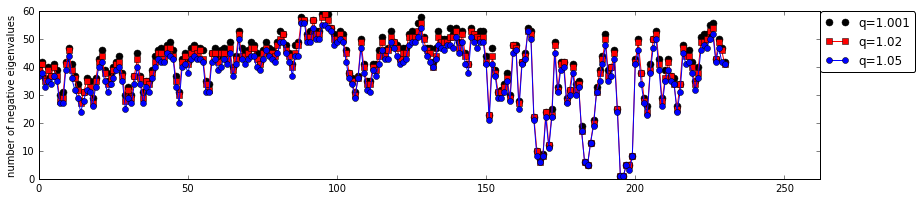

In [7]:
rcParams['figure.figsize'] = 14, 3
#plt.plot(neganum0005,"-*",label="q=1.0005",color="orange")
plt.plot(neganum0010,"o",markersize=7,color="black", label="q=1.001")
#plt.plot(neganum0050,"-s",markersize=6,color="black", label="q=1.005")
plt.plot(neganum0200,"-s",markersize=6,color="red", label="q=1.02")
plt.plot(neganum0500,"-o",markersize=6, color="blue", label="q=1.05")
plt.xlim(0,262)
plt.ylabel("number of negative eigenvalues")
plt.legend(bbox_to_anchor=(1, 1), loc=2, borderaxespad=0., fancybox=True)

In [16]:
##lista de numeros negativos para diferentes q T=20
#qs=[.0050,.001,.005,.010,.0200,.0500]
dias=20
T=dias
shift=10
N=293
lenret=len(Returns)
nummat=(len(Returns[0])-shift)/shift
neganum0005=[]
for i in xrange(0,int(nummat)):
    suma=0
    #print 1
    ww=np.loadtxt("/cueva/Susana/PaperPM/Values/evalorPM%dq1.0005T20.dat"%i)
    for valor in ww[:N-T+1]:
        if valor< -1e-16:
            suma+=1
            #print suma
    neganum0005.append(suma)

neganum0010=[]
for i in xrange(0,int(nummat)):
    suma=0
    #print 1
    ww=np.loadtxt("/cueva/Susana/PaperPM/Values/evalorPM%dq1.0010T20.dat"%i)
    for valor in ww[:N-T+1]:
        if valor< -1e-16:
            suma+=1
            #print suma
    neganum0010.append(suma)

neganum0500=[]
for i in xrange(0,int(nummat)):
    suma=0
    #print 1
    ww=np.loadtxt("/cueva/Susana/PaperPM/Values/evalorPM%dq1.0500T20.dat"%i)
    for valor in ww[:N-T+1]:
        if valor< -1e-16:
            suma+=1
            #print suma
    neganum0500.append(suma)
neganum0050=[]
for i in xrange(0,int(nummat)):
    suma=0
    #print 1
    ww=np.loadtxt("/cueva/Susana/PaperPM/Values/evalorPM%dq1.0050T20.dat"%i)
    for valor in ww[:N-T+1]:
        if valor< -1e-16:
            suma+=1
            #print suma
    neganum0050.append(suma)
neganum0200=[]
for i in xrange(0,int(nummat)):
    suma=0
    #print 1
    ww=np.loadtxt("/cueva/Susana/PaperPM/Values/evalorPM%dq1.0200T20.dat"%i)
    for valor in ww[:N-T+1]:
        if valor< -1e-16:
            suma+=1
            #print suma
    neganum0200.append(suma)

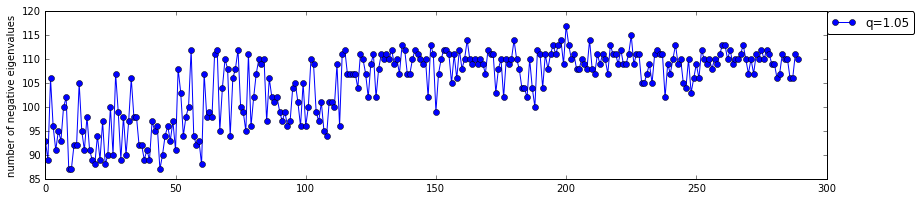

In [17]:
rcParams['figure.figsize'] = 14, 3
#plt.plot(neganum0005,"-*",label="q=1.0005",color="orange")
#plt.plot(neganum0010,"o",markersize=7,color="black", label="q=1.001")
#plt.plot(neganum0050,"-s",markersize=6,color="black", label="q=1.005")

#plt.plot(neganum0200,"-s",markersize=6,color="red", label="q=1.02")
plt.plot(neganum0500[::2],"-o",markersize=6, color="blue", label="q=1.05")
#plt.xlim(0,262)
plt.ylabel("number of negative eigenvalues")
plt.legend(bbox_to_anchor=(1, 1), loc=2, borderaxespad=0., fancybox=True)

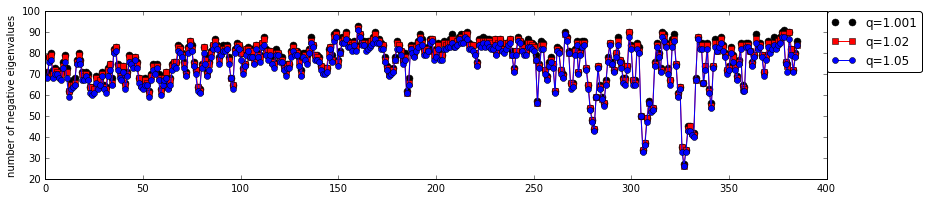

In [21]:
rcParams['figure.figsize'] = 14, 3
#plt.plot(neganum0005,"-*",label="q=1.0005",color="orange")
plt.plot(neganum0010,"o",markersize=7,color="black", label="q=1.001")
#plt.plot(neganum0050,"-s",markersize=6,color="black", label="q=1.005")
plt.plot(neganum0200,"-s",markersize=6,color="red", label="q=1.02")
plt.plot(neganum0500,"-o",markersize=6, color="blue", label="q=1.05")
#plt.xlim(0,262)
plt.ylabel("number of negative eigenvalues")
plt.legend(bbox_to_anchor=(1, 1), loc=2, borderaxespad=0., fancybox=True)

In [369]:
dias=22
shift=22
N=293
T=dias
lenret=len(Returns)
nummat=(len(Returns[0])-shift)/shift
neganum50=[]
neganum=[]
qs=[.0005,.0010,.0050,.0100,.0200,.0500]
for e in qs:
    q=1+e
    for i in xrange(int(nummat)-2):
        suma=0
        
        ww=np.load("/cueva/Susana/PaperPM/Values1/evalorPM%dq%.4fT%d.npy"%(i,q,dias))
        for valor in ww[:N-T+1]:
            if valor< -1e-16:
                suma+=1
            #print suma
        neganum.append(suma)
    neganum50.append(neganum)
    neganum=[]

In [370]:
N=293
dias=22
shift=22
lenret=len(Returns)
nummat=(len(Returns[0])-shift)/shift
Cmean=[]
CPmean=[]
for i in range(int(nummat)-2):
    CP=np.load("/cueva/Susana/PaperPM/MatCorrPM1/MatrizCorrPM%dq1.0010T%d.npy"%(i,dias))
    #cm=C.sum()
    #cm=cm/(N**2)
    cm=CP.mean()
    Cmean.append(cm)
    #CPmean.append(cpm)

In [32]:
dias=30
shift=15
N=293
T=dias
lenret=len(Returns)
nummat=(len(Returns[0])-shift)/shift
neganum50=[]
neganum=[]
qs=[.0005,.0010,.0050,.0100,.0200,.0500]
for e in qs:
    q=1+e
    for i in xrange(int(nummat)):
        suma=0
        
        ww=np.loadtxt("/cueva/Susana/PaperPM/Values/evalorPM%dq%.4fT%d.dat"%(i,q,dias))
        for valor in ww[:N-T+1]:
            if valor< -1e-16:
                suma+=1
            #print suma
        neganum.append(suma)
    neganum50.append(neganum)
    neganum=[]

In [35]:
N=293
dias=30
shift=15
lenret=len(Returns)
nummat=(len(Returns[0])-shift)/shift
Cmean=[]
CPmean=[]
Cstd=[]
for i in range(int(nummat)):
    CP=np.loadtxt("/cueva/Susana/PaperPM/MatCorrPM/MatrizCorrPM%dq1.0010T%d.dat"%(i,dias))
    #cm=C.sum()
    #cm=cm/(N**2)
    cm=CP.mean()
    Cmean.append(cm)
    cs=CP.std()
    Cstd.append(cs)
    #CPmean.append(cpm)

In [50]:
len(neganum50[1])


386

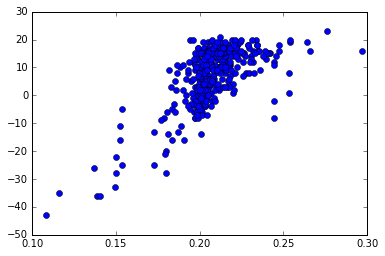

In [64]:

ss=neganum50[1][22]
lalala=[]
for i in xrange(len(neganum50[1])):
    lala=neganum50[1][i]-ss
    lalala.append(lala)
plt.plot(Cstd,lalala,"o")


In [27]:
vector=np.loadtxt(/cueva/Susana/PaperPM/Vector/evectorPM1dq1.0500fT44.dat)

SyntaxError: invalid syntax (<ipython-input-27-87272edefd73>, line 1)

In [96]:
year=[]
for i in xrange(23):
    anios=1992
    anios=+(anios+i)
    year.append(anios)
len(year)

23

In [356]:
nummat


263.0

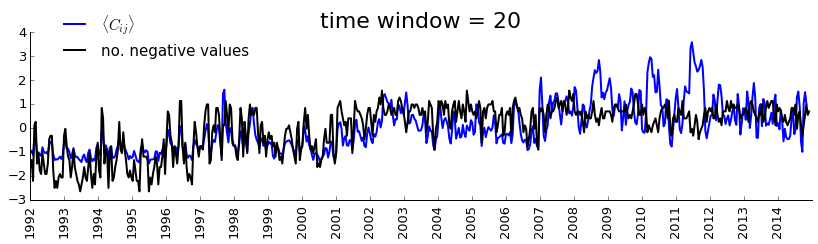

In [377]:
rcParams['figure.figsize'] = 14, 3
Cmean=np.asarray(Cmean)
Cmean=[(s-Cmean.mean())/Cmean.std() for s in Cmean]
Cmean=np.asarray(Cmean)
neganum50=np.asarray(neganum50)
neganum1=[(s-neganum50[1].mean())/neganum50[1].std() for s in neganum50[1]]
neganum1=np.asarray(neganum1)
fig, ax = plt.subplots()
nom=r"$ \langle C_{ij}\rangle$"
plt.plot(Cmean[:],linewidth=2, color="blue", label=nom)
plt.plot(neganum1[:],linewidth=2, color="black",label="no. negative values")

ax.spines['right'].set_visible(False)
ax.spines['top'].set_visible(False)
# Only show ticks on the left and bottom spines
ax.yaxis.set_ticks_position('left')
ax.xaxis.set_ticks_position('bottom')
salto=nummat/23
xx=np.arange(0,nummat,salto)
dias
plt.title("time window = %d"%dias, fontsize=22 )
plt.xticks(xx,year,rotation=90);
plt.xlim(0,nummat)
plt.legend(bbox_to_anchor=(0.02,1.2),frameon=False, loc=2, prop={"size":15})
plt.tick_params(labelsize=13)
titulo="/cueva/Susana/PaperPM/nagativt%d.pdf"%dias
plt.savefig(titulo,format="pdf", dpi=200,bbox_inches='tight')

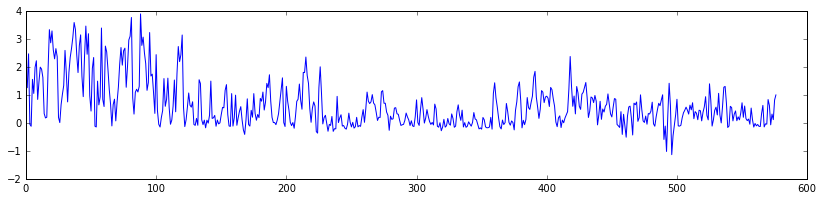

In [379]:
xxx=neganum1[:-2]*Cmean[:]

plt.plot(xxx)


In [380]:
def spectr_contrib(v1t,vt,n,t):
    #que tanto contribuye el espectro original con los evectores de PM
    suma=[]
    for i in xrange(n):
        sumvv=0
        for j in xrange(n-t+1,n):
            v1v=np.dot(v1t[:,i],vt[:,j])
            sumvv+=(v1v)**2  
        suma.append(sumvv)    
    return suma

In [ ]:
vectors=np.loadtxt("/cueva/Susana/PaperPM/Vectors/evector%d.dat"%i)

ValueError: x and y must have same first dimension

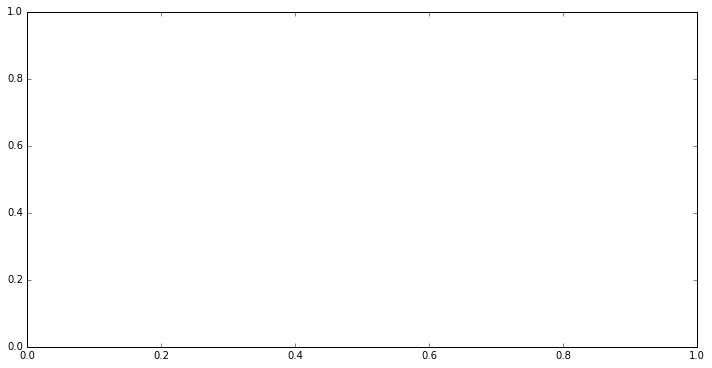

In [381]:
rcParams['figure.figsize'] = 12, 6
#plt.plot(Cmean,neganum0010,"o",markersize=7,color="black", label="q=1.001")
#plt.plot(neganum0050,"-s",markersize=6,color="black", label="q=1.005")
plt.plot(Cmean,neganum0200,"s",markersize=6,color="red", label="q=1.02")
plt.plot(Cmean,neganum0500,"o",markersize=6, color="blue", label="q=1.05")
plt.plot(Cmean,neganum0005,"*",label="q=1.0005",color="orange")
plt.ylabel("number of negative eigenvalues")
plt.legend(bbox_to_anchor=(1, 1), loc=2, borderaxespad=0., fancybox=True)

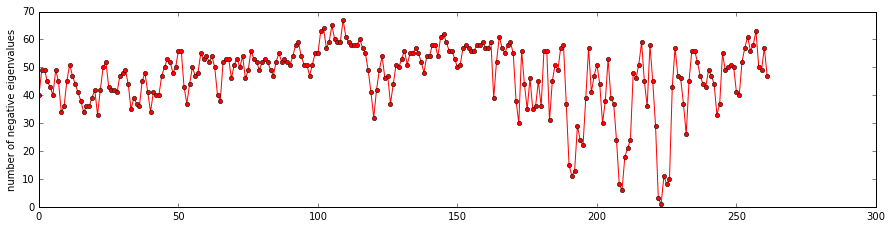

In [67]:
#Cuenta los evalores negativos
negativnum=[]
from pylab import rcParams
rcParams['figure.figsize'] = 15, 3.5


for i in xrange(0,262):
    suma=0
    ww=np.loadtxt("/cueva/Susana/PaperPM/Values/evalorPM%dq1.0500T44.dat"%i)
    for valor in ww[:274]:
        if valor< -1e-16:
            suma+=1
            #print suma
    negativnum.append(suma)
num=6
indice = np.arange(0,160,num)
fecha=d[0::44]
fechalabel=fecha[::num]
#plt.xticks(indice[:-1],[remove_cruft(s) for s in fechalabel], rotation = 90)
plt.ylabel("number of negative eigenvalues")
plt.plot(negativnum,"-o", color="r", markersize=4.4, markevery=1)


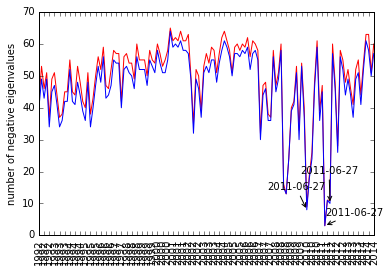

In [60]:
#Cuenta los evalores negativos
negativnum2=[]
for i in xrange(0,262,2):
    suma=0
    ww=np.loadtxt("evalorPM%dq1.01.dat"%i)
    for valor in ww[:249]:
        if valor< -1e-14:
            suma+=1
            #print suma
    negativnum2.append(suma)
num=2
indice = np.arange(0,160,num)
fecha=d[0::44]
fechalabel=fecha[::num]
plt.xticks(indice[:-1],[remove_cruft(s) for s in fechalabel], rotation = 90)
plt.ylabel("number of negative eigenvalues")
plt.plot(negativnum2, color="r")
plt.plot(negativnum)
dia=fecha[111]
plt.annotate(dia, xy=(111, 3), xycoords='data',xytext=(-0, 10), textcoords='offset points', arrowprops=dict(arrowstyle="->"))
plt.annotate(dia, xy=(104, 8), xycoords='data',xytext=(-40, 20), textcoords='offset points', arrowprops=dict(arrowstyle="->"))
plt.annotate(dia, xy=(113, 10), xycoords='data',xytext=(-30, 30), textcoords='offset points', arrowprops=dict(arrowstyle="->"))

In [115]:
for i in xrange(131):
    if negativnum[i]<10:
        print i, negativnum[i]
#print negativnum[222/2], 226/2

104 8
111 3


In [35]:
def remove_cruft(s):
    return s[:-6]

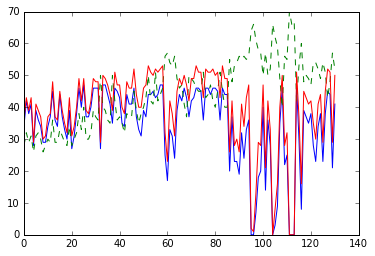

In [57]:
#numeros negativos para CWOE
WWnega=[]
for i in xrange(0,262,2):
    suma=0
    for valor in cwoe[i][:N-T+1]:
        if valor < 1e-13:
            suma+=1
    WWnega.append(suma)
WWsecnega=[]
for i in xrange(0,262,2):
    suma=0
    for valor in cwoesec[i][:N-T+1]:
        if valor < 1e-13:
            suma+=1
    WWsecnega.append(suma)
WWsec2nega=[]
for i in xrange(0,262,2):
    suma=0
    for valor in cwoenosec[i][:N-T+1]:
        if valor < 1e-13:
            suma+=1
    WWsec2nega.append(suma)
    
    
plt.plot(WWnega)
plt.plot(WWsecnega, "--")
plt.plot(WWsec2nega, "red");
 
    

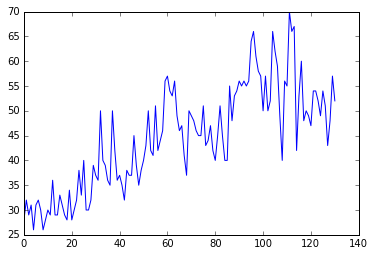

In [25]:
#numeros negativos para CWOE
WWsecnega=[]
for i in xrange(0,262,2):
    suma=0
    for valor in cwoesec[i][:249]:
        if valor < 1e-14:
            suma+=1
    WWsecnega.append(suma)
plt.plot(WWsecnega);

23

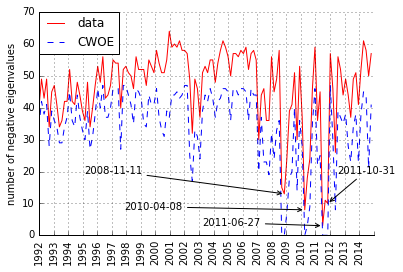

In [118]:
num=5.695
indice = np.arange(0,131,num)

fecha=d[0::44]
#fechalabel=fecha[::num]
fig, ax = plt.subplots()
ax.spines['right'].set_visible(False)
ax.spines['top'].set_visible(False)
ax.yaxis.set_ticks_position('left')
ax.xaxis.set_ticks_position('bottom')
#plt.plot(negativnum2, "--",color="black", label="q=1.01")
plt.plot(negativnum, color="r",label="data")
plt.plot(WWnega,"--", label="CWOE")
#plt.plot(WWsec2nega, "blue")
#plt.plot(WWsecnega,"--")
#plt.plot(negativnum3, color="b",label="q=1.10")
plt.legend(bbox_to_anchor=(0, 1), loc=2, borderaxespad=0.)
plt.xticks(indice[:],anios, rotation = 90)
#plt.xticks(indice,[remove_cruft(s) for s in fechalabel], rotation = 90)
plt.ylabel("number of negative eigenvalues")
plt.xlim(0,131)
dia=fecha[96]
dia2=fecha[104]
dia3=fecha[111]
dia4=fecha[113]
plt.annotate(dia3, xy=(111, 3), xycoords='data',xytext=(-120, 0), textcoords='offset points', arrowprops=dict(arrowstyle="->"))
plt.annotate(dia2, xy=(104, 8), xycoords='data',xytext=(-180, 0), textcoords='offset points', arrowprops=dict(arrowstyle="->"))
plt.annotate(dia4, xy=(113, 10), xycoords='data',xytext=(10, 30),textcoords='offset points', arrowprops=dict(arrowstyle="->"))
plt.annotate(dia, xy=(96, 13), xycoords='data',xytext=(-200, 20), textcoords='offset points', arrowprops=dict(arrowstyle="->"))
plt.grid()
plt.savefig('/cueva/Susana/SusanaDos/tesis_latex/valornegativo.eps', format='eps', dpi=1000)


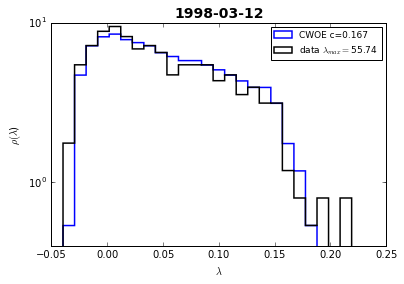

In [365]:
mat=70
fecha=d[(mat*22)]   
N=293
T=44
plt.title('%s'%fecha, fontsize=14, fontweight='bold')
ww=np.loadtxt("/cueva/Susana/SusanaDos/evaluesyevectosQs/evalorPM%dq1.05.dat"%mat)
#wwq=np.loadtxt("/cueva/Susana/SusanaDos/evaluesyevectosQs/evalorPM%dq1.10.dat"%mat)
#wwq1=np.loadtxt("/cueva/Susana/SusanaDos/evaluesyevectosQs/evalorPM%dq1.15.dat"%mat)
#print ww-ww1
nomb=r"data $\lambda_{max}=$"+str(round(np.max(ww),2))
cc="CWOE c="+str(round(Cmean[mat],3))
binlim = np.linspace(-.05,.25,30)
#hist0,bins0,algo0=plt.hist(woe[:N-T+1],bins=binlim,color="red", histtype='step', normed=N-T+1, label="WOE", linewidth=1.3)
#hist01,bins01,algo01=plt.hist(cwoesec2[mat][:249],bins=30,color="r", histtype='step', normed=1, label="CWOE", linewidth=2)

hist2,bins2,algo2=plt.hist(cwoe[mat][:N-T+1], bins=binlim ,color="blue", normed=N-T+1, histtype='step', label=cc, linewidth=1.5)
#hist3,bins3,algo3=plt.hist(wwq1[:250], bins=30, color = "#E69F00", histtype='step', label="q=1.15", linewidth=2.5);
hist1,bins1,algo1=plt.hist(ww[:N-T+1],bins=binlim, color = "black", histtype='step',normed=N-T+1, label=nomb, linewidth=1.5)
plt.legend(prop={'size': 9})
axes = plt.gca()
ax.set_ylim([0, 250])
xmax=np.max(ww[:250])
xmin=np.min(ww[:250])
xmedio=0.5*(xmax+xmin)
plt.yscale('symlog')
#plt.xticks([round(xmax,3),round(xmin,3),round(xmedio,3)])
plt.xlabel(r"$\lambda$")
plt.ylabel(r"$\rho(\lambda$)")
titulo="/cueva/Susana/SusanaDos/tesis_latex/es%d.pdf"%mat
plt.savefig(titulo, format='pdf', dpi=1000)

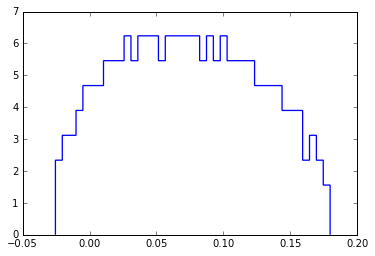

In [392]:
plt.hist(woe[:250],40, normed=N-T+1, histtype='step', label="CWOE", linewidth=1.3);

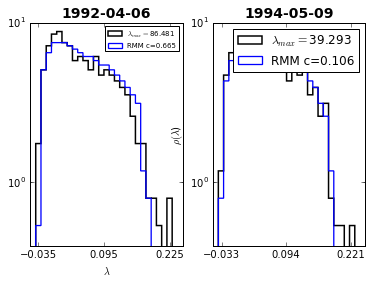

In [308]:
mat=2
mat1=26
mat2=208
mat3=192
fecha=d[(mat*22)]   
fecha1=d[(mat1*22)]   
N=293
T=44
fig, (ax, ax1) = plt.subplots(1, 2, sharey=False)
n_bins = 40
binBoundaries = np.linspace(-.05,.25,30)
binBoundaries1 = np.linspace(-.05,.25,30)
ax.set_title('%s'%fecha, fontsize=14, fontweight='bold')
ax.hist(ww[:N-T+1],bins=binBoundaries, color = "black", histtype='step',normed=N-T+1, label=nomb, linewidth=1.5)
ax.hist(cwoe[mat][:N-T+1], bins=binBoundaries ,color="blue", normed=N-T+1, histtype='step',label=cc, linewidth=1.3)
ax.legend(prop={'size': 7})
ax.set_yscale('symlog')


cc1="RMM c="+str(round(Cmean[mat1],3))
ax1.set_title('%s'%fecha1, fontsize=14, fontweight='bold')
ww1=np.loadtxt("/cueva/Susana/SusanaDos/evaluesyevectosQs/evalorPM%dq1.05.dat"%mat1)
nomb1=r"$\lambda_{max}=$"+str(round(np.max(ww1),3))
ax1.hist(ww1[:N-T+1],bins=binBoundaries1, color = "black", histtype='step',normed=N-T+1, label=nomb1, linewidth=1.5)
ax1.hist(cwoe[mat1][:N-T+1], bins=binBoundaries1, color="blue", normed=N-T+1, histtype='step', label=cc1, linewidth=1.3)
ax1.legend(prop={'size': 7})
ax1.set_yscale('symlog')
"""
ax2.set_title('%s'%fecha, fontsize=14, fontweight='bold')
ww2=np.loadtxt("/cueva/Susana/SusanaDos/evaluesyevectosQs/evalorPM%dq1.05.dat"%mat2)
ax2.hist(ww[:N-T+1],bins=n_bins, color = "black", histtype='step',normed=N-T+1, label="q=1.05", linewidth=1.5)
ax2.hist(cwoe[mat2][:N-T+1], bins=n_bins ,color="red", normed=N-T+1, histtype='step', label="CWOE", linewidth=1.3)

ax3.set_title('%s'%fecha, fontsize=14, fontweight='bold')
ww3=np.loadtxt("/cueva/Susana/SusanaDos/evaluesyevectosQs/evalorPM%dq1.05.dat"%mat3)
ax3.hist(ww[:N-T+1],bins=n_bins, color = "black", histtype='step',normed=N-T+1, label="q=1.05", linewidth=1.5)
ax3.hist(cwoe[mat3][:N-T+1], bins=n_bins ,color="red", normed=N-T+1, histtype='step', label="CWOE", linewidth=1.3)
"""
#axes = plt.gca()
#ax.set_ylim([0, 300])
#ax1.set_ylim([0,300])
xmax=np.max(ww[:N-T+1])
xmin=np.min(ww[:N-T+1])
xmedio=0.5*(xmax+xmin)
ax.set_xticks([round(xmax,3),round(xmin,3),round(xmedio,3)])
ax.set_xlabel(r"$\lambda$")
ax1.set_ylabel(r"$\rho(\lambda$)")
xmax1=np.max(ww1[:N-T+1])
xmin1=np.min(ww1[:N-T+1])
xmedio1=0.5*(xmax1+xmin1)
ax1.set_xticks([round(xmax1,3),round(xmin1,3),round(xmedio1,3)])
"""
xmax2=np.max(ww[:N-T+1])
xmin2=np.min(ww[:N-T+1])
xmedio2=0.5*(xmax+xmin)
ax2.set_xticks([round(xmax2,3),0,round(xmedio2,3)])
ax2.set_xlabel(r"$\lambda$")
ax2.set_ylabel(r"$\rho(\lambda$)")
xmax3=np.max(ww[:N-T+1])
xmin3=np.min(ww[:N-T+1])
xmedio3=0.5*(xmax+xmin)
ax3.set_xticks([round(xmax,3),0,round(xmedio,3)])
ax3.set_xlabel(r"$\lambda$")
"""
plt.legend()

In [215]:
N=293
Cmean=[]

CPmean=[]
for i in range(262):
    #fecha=d[i]
    C=np.loadtxt("/cueva/Susana/SusanaDos/SYP-q1.05/MatrizCorr%d.dat"%i)
    #CP=np.loadtxt("/cueva/Susana/SusanaDos/SYP-q1.05/MatrizCorrPM%dq1.10.dat"%i)
    cm=C.sum()-N
    cm=cm/(N**2-N)
    Cmean.append(cm)
    #CPmean.append(cpm)


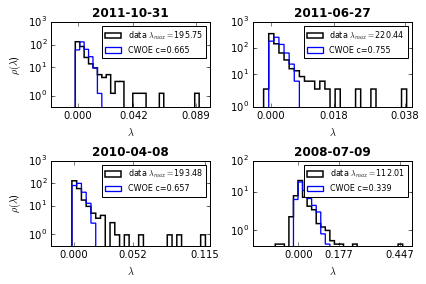

In [336]:
mat=226
mat1=222
mat2=208
mat3=188
fecha=d[(mat*22)]   
fecha1=d[(mat1*22)] 
fecha2=d[(mat2*22)] 
fecha3=d[(mat3*22)] 
N=293
T=44
fig, axes = plt.subplots(nrows=2, ncols=2)
ax, ax1, ax2, ax3 = axes.flatten()
n_bins = 30
binBoundaries = np.linspace(-.002,.095,30)
binBoundaries1 = np.linspace(-.002,.04,30)
binBoundaries2 = np.linspace(-.002,.12,30)
binBoundaries3 = np.linspace(-.102,.48,30)
ax.set_title('%s'%fecha, fontsize=12, fontweight='bold')
ww=np.loadtxt("/cueva/Susana/SusanaDos/evaluesyevectosQs/evalorPM%dq1.05.dat"%mat)
nomb=r"data $\lambda_{max}=$"+str(round(np.max(ww),2))
cc="CWOE c="+str(round(Cmean[mat],3))
#ax.hist(cwoenosec[mat][:N-T+1], bins=binBoundaries, color = "gray",  normed=N-T+1, histtype='step', linewidth=1.5)
ax.hist(ww[:N-T+1],bins=binBoundaries, color = "black", histtype='step',normed=N-T+1, label=nomb, linewidth=1.5)
ax.hist(cwoe[mat][:N-T+1], bins=binBoundaries ,color="blue", normed=N-T+1, histtype='step',label=cc, linewidth=1.3)
ax.legend(prop={'size': 8})
ax.set_yscale('symlog')

cc1="CWOE c="+str(round(Cmean[mat1],3))
ax1.set_title('%s'%fecha1, fontsize=12, fontweight='bold')
ww1=np.loadtxt("/cueva/Susana/SusanaDos/evaluesyevectosQs/evalorPM%dq1.05.dat"%mat1)
nomb1=r"data $\lambda_{max}=$"+str(round(np.max(ww1),2))
ax1.hist(ww1[:N-T+1],bins=binBoundaries1, color = "black", histtype='step',normed=N-T+1, label=nomb1, linewidth=1.5)
ax1.hist(cwoe[mat1][:N-T+1], bins=binBoundaries1, color="blue", normed=N-T+1, histtype='step', label=cc1, linewidth=1.3)
ax1.legend(prop={'size': 8})
ax1.set_yscale('symlog')

ax2.set_title('%s'%fecha2, fontsize=12, fontweight='bold')
ww2=np.loadtxt("/cueva/Susana/SusanaDos/evaluesyevectosQs/evalorPM%dq1.05.dat"%mat2)
nomb2=r"data $\lambda_{max}=$"+str(round(np.max(ww2),2))
cc2="CWOE c="+str(round(Cmean[mat2],3))
ax2.hist(ww2[:N-T+1],bins=binBoundaries2, color = "black", histtype='step',normed=N-T+1, label=nomb2, linewidth=1.5)
ax2.hist(cwoe[mat2][:N-T+1], bins=binBoundaries2 ,color="blue", normed=N-T+1, histtype='step', label=cc2, linewidth=1.3)
#ax2.hist(woe[:N-T+1], bins=n_bins ,color="blue", normed=N-T+1, histtype='step',  linewidth=1.3)
ax2.legend(prop={'size': 8})
#ax2.hist(cwoesec2[mat2][:N-T+1], bins=n_bins ,color="yellow", normed=N-T+1, histtype='step',  linewidth=1)
ax2.set_yscale('symlog')

ax3.set_title('%s'%fecha3, fontsize=12, fontweight='bold')
ww3=np.loadtxt("/cueva/Susana/SusanaDos/evaluesyevectosQs/evalorPM%dq1.05.dat"%mat3)
nomb3=r"data $\lambda_{max}=$"+str(round(np.max(ww3),2))
ax3.hist(ww3[:N-T+1],bins=binBoundaries3, color = "black", histtype='step',normed=N-T+1,  linewidth=1.5, label=nomb3)
cc3="CWOE c="+str(round(Cmean[mat3],3))
ax3.hist(cwoe[mat3][:N-T+1], bins=binBoundaries3 ,color="blue", normed=N-T+1, histtype='step', label=cc3, linewidth=1.3)
xmax3=np.max(ww3[:N-T+1])
xmin3=np.min(ww3[:N-T+1])
xmedio3=0.5*(xmax3+xmin3)
ax3.set_xticks([round(xmax3,3),0,round(xmedio3,3)])
ax3.set_xlabel(r"$\lambda$")
ax3.legend(prop={'size': 8})
ax3.set_yscale('symlog')
#axes = plt.gca()
#ax.set_ylim([0, 300])
#ax1.set_ylim([0,300])

xmax=np.max(ww[:N-T+1])
xmin=np.min(ww[:N-T+1])
xmedio=0.5*(xmax+xmin)
ax.set_xticks([round(xmax,3),0,round(xmedio,3)])
ax.set_xlabel(r"$\lambda$")
ax.set_ylabel(r"$\rho(\lambda$)")
xmax1=np.max(ww1[:N-T+1])
xmin1=np.min(ww1[:N-T+1])
xmedio1=0.5*(xmax1+xmin1)
ax1.set_xticks([round(xmax1,3),0,round(xmedio1,3)])
ax1.set_xlabel(r"$\lambda$")
xmax2=np.max(ww2[:N-T+1])
xmin2=np.min(ww2[:N-T+1])
xmedio2=0.5*(xmax2+xmin2)
ax2.set_xticks([round(xmax2,3),0,round(xmedio2,3)])
ax2.set_xlabel(r"$\lambda$")
ax2.set_ylabel(r"$\rho(\lambda$)")

fig.tight_layout()
titulo="/cueva/Susana/SusanaDos/tesis_latex/4figES.pdf"
plt.savefig(titulo, format='pdf', dpi=1000)

In [21]:
plt.plot(bins0[:-1],hist0,marker="o")
plt.plot(bins1[:-1],hist1,marker="v")
#plt.plot(bins3[:-1],hist3,marker="s")
#plt.plot(bins0[:-1],hist3,marker="<")
xmax=np.max(ww[:250])
xmin=np.min(ww[:250])
xmedio=0.5*(xmax+xmin)
plt.xticks([round(xmax,3),round(xmin,3),round(xmedio,3)])
plt.xlabel(r"$\lambda$")
plt.ylabel(r"$\rho(\lambda$)")


NameError: name 'bins0' is not defined

In [85]:
#Marćenko pastur 

def marcenkopasturpdf(x, c):
    # Marchenko Pastur Density Function for c > 1
    ub = (1 + sqrt(c))**2
    lb = (1 - sqrt(c))**2 
    mp = zeros(len(x))
    
    # Figure out indices where mp is to be calculated
    lbidx = where(x > lb)
    ubidx = where(x < ub)  
    a = lbidx[0][0]
    b = ubidx[-1][-1]
    xh = x[a:b+1]
    # MP distribution
    mp[a:b+1] = sqrt((xh - lb)*(ub - xh))/(2*pi*c*xh)              
    return (lb, ub, mp)

In [143]:
500/.25

2000.0

/home/jose/anaconda2/lib/python2.7/site-packages/ipykernel/__main__.py:4: RuntimeWarning: invalid value encountered in sqrt


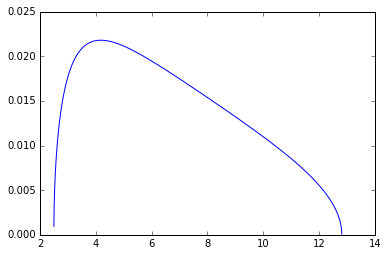

In [232]:
x=np.arange(2,14,.001)
lmax=(sqrt(N/T)+1)**2
lmin=(sqrt(N/T)-1)**2
y= sqrt((lmax-x)*(x-lmin))/(2*pi*x*(N/T))
plt.plot(x,y)

(array([ 0.2438522 ,  0.1219261 ,  0.1219261 ,  0.18288915,  0.18288915,
         0.18288915,  0.06096305,  0.2438522 ,  0.06096305,  0.1219261 ,
         0.18288915,  0.06096305,  0.06096305,  0.1219261 ,  0.06096305,
         0.06096305,  0.06096305,  0.18288915,  0.        ,  0.        ,
         0.06096305,  0.06096305,  0.        ,  0.        ,  0.        ,
         0.06096305,  0.        ,  0.        ,  0.        ,  0.06096305]),
 array([  2.29332703,   2.68388367,   3.07444032,   3.46499696,
          3.8555536 ,   4.24611025,   4.63666689,   5.02722354,
          5.41778018,   5.80833682,   6.19889347,   6.58945011,
          6.98000675,   7.3705634 ,   7.76112004,   8.15167668,
          8.54223333,   8.93278997,   9.32334662,   9.71390326,
         10.1044599 ,  10.49501655,  10.88557319,  11.27612983,
         11.66668648,  12.05724312,  12.44779977,  12.83835641,
         13.22891305,  13.6194697 ,  14.01002634]),
 <a list of 1 Patch objects>)

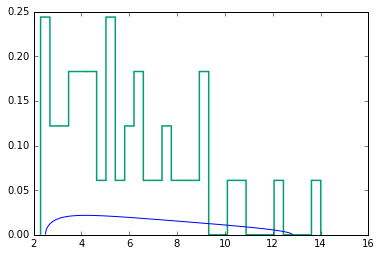

In [233]:
mat=36
ww=np.loadtxt("/cueva/Susana/SusanaDos/evaluesyevectosQs/evalorPM%dq1.05.dat"%mat)
xmax=np.max(ww[250:292])
xmin=np.min(ww[250:292])
#lb, ub, mp = marcenkopasturpdf(np.arange(0,15,.01), N/T)
plt.plot(x,y)
plt.hist(ww[250:292], bins=30, color = "#009E73",normed=T/N, histtype='step', label="q=1.05", linewidth=1.5)
#xlim((lb,ub))

In [ ]:

plt.title('%s'%fecha, fontsize=14, fontweight='bold')
mat=36
ww=np.loadtxt("/cueva/Susana/SusanaDos/evaluesyevectosQs/evalorPM%dq1.05.dat"%mat)
#wwq=np.loadtxt("/cueva/Susana/SusanaDos/evaluesyevectosQs/evalorPM%dq1.10.dat"%mat)
#wwq1=np.loadtxt("/cueva/Susana/SusanaDos/evaluesyevectosQs/evalorPM%dq1.15.dat"%mat)
#print ww-ww1
plt.hist(cwoe[mat][250:292],bins=40,color="b", histtype='step', normed=N, label="CWOE", linewidth=1.5)
a,b,c=plt.hist(ww[250:292], bins=40, color = "#009E73",normed=N, histtype='step', label="q=1.05", linewidth=1.5)
#plt.hist(wwq[250:292], bins=20, color = "#999999",normed=N, histtype='step', label="q=1.10", linewidth=2.5)
plt.hist(woe[250:292], bins=40, color = "#E69F00", normed=N, histtype='step', label="WOE",linewidth=1.5);
plt.legend()
xmax=np.max(ww[250:292])
xmin=np.min(ww[250:292])
xmedio=0.5*(xmax+xmin)
plt.xticks([round(xmax,3),round(xmin,3),round(xmedio,3)])
plt.xlabel(r"$\lambda$")
plt.ylabel(r"$\rho(\lambda$)")
#plt.yscale('symlog')

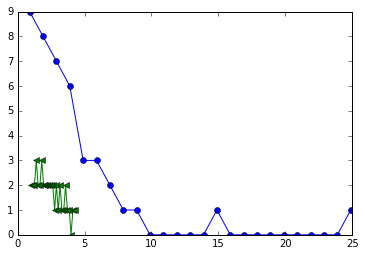

In [88]:
hist,bins=np.histogram(ww[250:292], bins = 25)
plt.plot(bins[:-1],hist,marker="o")
hist0,bins0=np.histogram(cwoe[mat][250:292],bins=25)
plt.plot(bins0[:-1],hist0,marker="<")

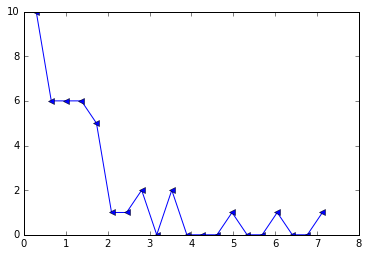

In [40]:
plt.plot(b[:-1],a,marker="<")

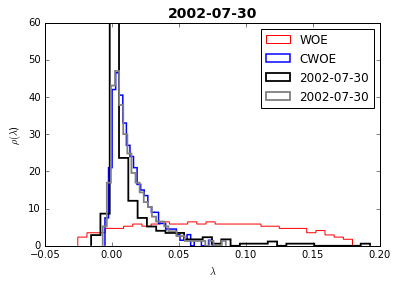

In [65]:
#espectro emergente diferentes fechas
mat=120
#fecha1=d[(36*22)]   
#fecha2=d[(226*22)]
fecha=d[(mat*22)]
plt.title('%s'%fecha, fontsize=14, fontweight='bold')
#plt.title('%s'%fecha, fontsize=14, fontweight='bold')
#ww=np.loadtxt("/cueva/Susana/SusanaDos/evaluesyevectosQs/evalorPM36q1.05.dat")
#wwq=np.loadtxt("/cueva/Susana/SusanaDos/evaluesyevectosQs/evalorPM226q1.05.dat")
ww=np.loadtxt("/cueva/Susana/SusanaDos/evaluesyevectosQs/evalorPM%dq1.05.dat"%mat)
bin_n=30
binBoundaries = np.linspace(-.05,.4,30)
plt.hist(woe[:N-T+1],bin_n, color = "red", histtype='step', label="WOE", linewidth=1,normed=N-T+1)
plt.hist(cwoe[mat][:N-T+1], bin_n, color = "blue", histtype='step', label="CWOE", linewidth=1.5,normed=N-T+1)
plt.hist(ww[:N-T+1], bin_n, color = "black", histtype='step', label=fecha, linewidth=1.8,normed=N-T+1)
plt.hist(cwoenosec[mat][:N-T+1], bin_n, color = "gray", histtype='step', label=fecha, linewidth=1.8,normed=N-T+1)
#plt.hist(wwq[:250], bin_n,  color = "#999999",histtype='step', label=fecha2, linewidth=1.5,normed=N-T+1)

#plt.hist(wwq1[:250], 40, color = "blue", histtype='step', label=fecha3, linewidth=1.8, normed=N-T+1);
plt.legend()
#xmax=np.max(wwq1[:250])
#xmin=np.min(wwq1[:250])
#xmedio=0.5*(xmax+xmin)
#plt.xticks([round(xmax,3),round(xmin,3),round(xmedio,3)])
plt.xlabel(r"$\lambda$")
plt.ylabel(r"$\rho(\lambda$)")

In [167]:
ww[249]

0.115046600079

In [149]:
96*2

192

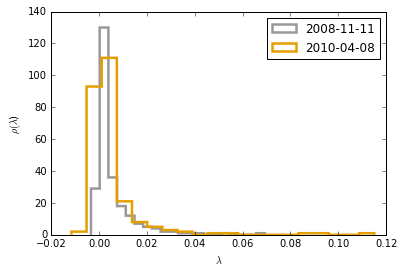

In [23]:
#espectro emergente diferentes fechas
#mat=197
fecha1=d[(208*22)]   
fecha2=d[(222*22)]
fecha3=d[(226*22)]
fecha4=d[(96*2*22)]
#plt.title('%s'%fecha, fontsize=14, fontweight='bold')
ww=np.loadtxt("/cueva/Susana/SusanaDos/evaluesyevectosQs/evalorPM208q1.05.dat")
wwq=np.loadtxt("/cueva/Susana/SusanaDos/evaluesyevectosQs/evalorPM222q1.05.dat")
wwq1=np.loadtxt("/cueva/Susana/SusanaDos/evaluesyevectosQs/evalorPM226q1.05.dat")
wwq2=np.loadtxt("/cueva/Susana/SusanaDos/evaluesyevectosQs/evalorPM192q1.05.dat")
#print ww-ww1
plt.hist(wwq2[:250], 20, color ="#999999", histtype='step', label=fecha4, linewidth=2.5)
plt.hist(ww[:250], 20,color =  "#E69F00", histtype='step', label=fecha1, linewidth=2.5)
#plt.hist(wwq[:250], 20, color =  "#56B4E9",histtype='step', label=fecha2, linewidth=2.5)
#plt.hist(wwq1[:250], 20, color = "#009E73", histtype='step', label=fecha3, linewidth=2.5);

plt.legend()

#xmax=np.max(wwq1[:250])
#xmin=np.min(wwq1[:250])
#xmedio=0.5*(xmax+xmin)
#plt.xticks([round(xmax,3),round(xmin,3),round(xmedio,3)])
plt.xlabel(r"$\lambda$")
plt.ylabel(r"$\rho(\lambda$)")

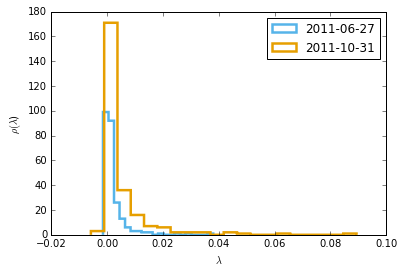

In [24]:
plt.hist(wwq[:250], 20, color =  "#56B4E9",histtype='step', label=fecha2, linewidth=2.5)
plt.hist(wwq1[:250], 20, color = "#E69F00", histtype='step', label=fecha3, linewidth=2.5);
plt.xlabel(r"$\lambda$")
plt.ylabel(r"$\rho(\lambda$)")

plt.legend()


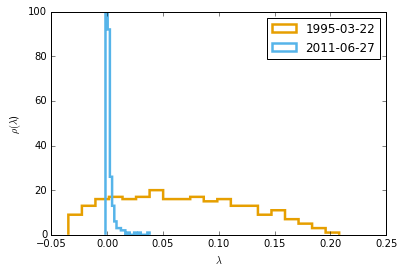

In [33]:
#espectro emergente diferentes fechas 
#mat=197
fecha1=d[(36*22)]   
fecha2=d[(222*22)]
#fecha3=d[(222*22)]
#plt.title('%s'%fecha, fontsize=14, fontweight='bold')
ww=np.loadtxt("/cueva/Susana/SusanaDos/evaluesyevectosQs/evalorPM36q1.05.dat")
wwq=np.loadtxt("/cueva/Susana/SusanaDos/evaluesyevectosQs/evalorPM222q1.05.dat")
#wwq1=np.loadtxt("/cueva/Susana/SusanaDos/evaluesyevectosQs/evalorPM222q1.05.dat")
#print ww-ww1
plt.hist(ww[:250], 20,  color = "#E69F00",  histtype='step', label=fecha1,linewidth=2.5)
plt.hist(wwq[:250], 20, color = "#56B4E9", histtype='step', label=fecha2, linewidth=2.5)
#plt.hist(wwq1[:250], 20, color = "red",  histtype='step', label=fecha3);
plt.legend()
#xmax=np.max(wwq1[:250])
#xmin=np.min(wwq1[:250])
#xmedio=0.5*(xmax+xmin)
#plt.xticks([round(xmax,3),round(xmin,3),round(xmedio,3)])
plt.xlabel(r"$\lambda$")
plt.ylabel(r"$\rho(\lambda$)")

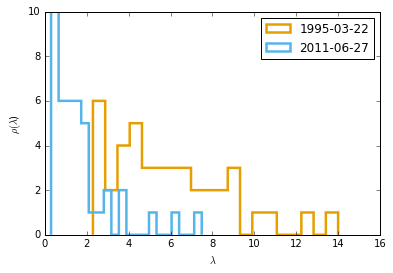

In [32]:
#espectro original-diferentes fechas
fecha1=d[(36*22)]   
fecha2=d[(222*22)]
#fecha3=d[(222*22)]
#plt.title('%s'%fecha, fontsize=14, fontweight='bold')
ww=np.loadtxt("/cueva/Susana/SusanaDos/evaluesyevectosQs/evalorPM36q1.05.dat")
wwq=np.loadtxt("/cueva/Susana/SusanaDos/evaluesyevectosQs/evalorPM222q1.05.dat")
#wwq1=np.loadtxt("/cueva/Susana/SusanaDos/evaluesyevectosQs/evalorPM222q1.05.dat")
#print ww-ww1
plt.hist(ww[250:292], 20, color = "#E69F00", histtype='step', label=fecha1,linewidth=2.5)
plt.hist(wwq[250:292], 20, color = "#56B4E9",  histtype='step', label=fecha2,linewidth=2.5)
#plt.hist(wwq1[250:292], 20, color = "red", normed=1, histtype='step', label=fecha3);
plt.legend()
plt.xlabel(r"$\lambda$")
plt.ylabel(r"$\rho(\lambda$)")
#xmax=np.max(wwq1[:250])

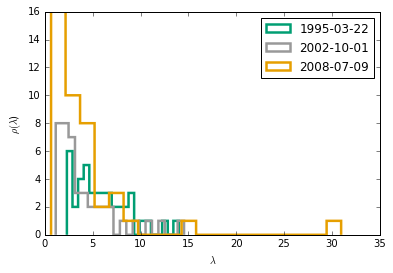

In [41]:
#Espectro original-diferentes fechas
fecha1=d[(36*22)]   
fecha2=d[(122*22)]
fecha3=d[(188*22)]
#plt.title('%s'%fecha, fontsize=14, fontweight='bold')
ww=np.loadtxt("/cueva/Susana/SusanaDos/evaluesyevectosQs/evalorPM36q1.05.dat")
wwq=np.loadtxt("/cueva/Susana/SusanaDos/evaluesyevectosQs/evalorPM122q1.05.dat")
wwq1=np.loadtxt("/cueva/Susana/SusanaDos/evaluesyevectosQs/evalorPM188q1.05.dat")
#print ww-ww1
plt.hist(ww[250:292],20,  color = "#009E73", histtype='step', label=fecha1, linewidth=2.5)
plt.hist(wwq[250:292], 20,color = "#999999", histtype='step', label=fecha2,linewidth=2.5)
plt.hist(wwq1[250:292], 20, color =  "#E69F00",  histtype='step', label=fecha3,linewidth=2.5);
plt.legend()
plt.xlabel(r"$\lambda$")
plt.ylabel(r"$\rho(\lambda$)")
#xmax=np.max(wwq1[:250])

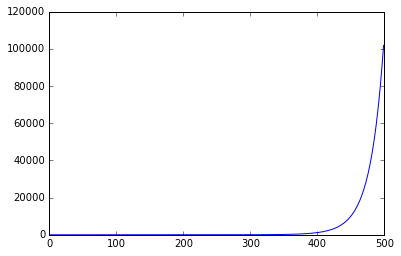

In [420]:
x=np.arange(0,5,.01)
P_rmt=(1/sqrt(2*math.pi))*exp(x**2/2)
plot(P_rmt)

In [28]:
Cmean=[]
CPmean=[]
#CPvar=[]
for i in range(0,262,2):
    
    C=np.loadtxt("/cueva/Susana/SusanaDos/SYP-q1.05/MatrizCorr%d.dat"%i)
    CP=np.loadtxt("/cueva/Susana/SusanaDos/SYP-q1.05/MatrizCorrPM%dq1.05.dat"%i)
    cm=C.mean()
    cpm=CP.mean()
    #cv=CP.var()
    #CPvar.append(cv)
    Cmean.append(cm)
    CPmean.append(cpm)

In [29]:
valorpeque=[]
for i in xrange(0,262,2):
    ww=np.loadtxt("/cueva/Susana/SusanaDos/evaluesyevectosQs/evalorPM%dq1.05.dat"%i)
    valorpeque.append(ww[250:291].mean())

In [30]:
valor2=[]
for i in xrange(0,262,2):
    #ww=np.loadtxt("/cueva/Susana/SusanaDos/evaluesyevectosQs/evalorPM%dq1.05.dat"%i)
    valor2.append(cwoe[i][292])

In [31]:
valor3=[]
for i in xrange(0,262,2):
    ww=np.loadtxt("/cueva/Susana/SusanaDos/evaluesyevectosQs/evalorPM%dq1.05.dat"%i)
    valor3.append(ww[292])

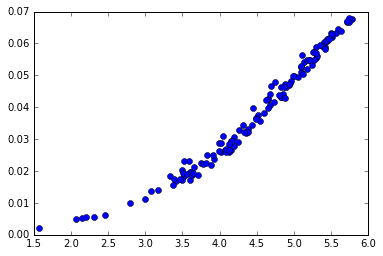

In [32]:
plt.plot(valorpeque,m1list,"o")


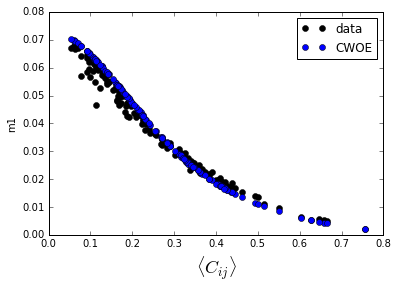

In [136]:
plt.plot(Cmean[::2],m1list,"o",color="black", label="data")
plt.plot(Cmean[::2],m1,"bo", label="CWOE")
#plt.plot(Cmean,m2sec, "<r")
plt.ylabel("m1")
plt.xlabel(r"$ \langle C_{ij}\rangle$", size=18)
plt.legend()
plt.savefig('/cueva/Susana/SusanaDos/tesis_latex/m1Cmean.eps', format='eps', dpi=1000)

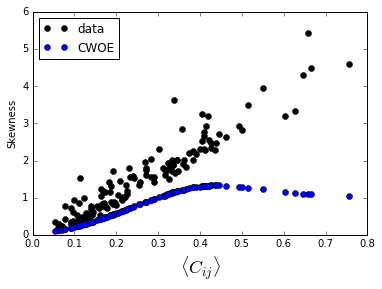

In [139]:
plt.plot(Cmean[::2],skwns,"o",color="black", label="data")
plt.plot(Cmean[::2],m3,"bo", label="CWOE")
#plt.plot(Cmean,m2sec, "<r")
plt.ylabel("Skewness")
plt.xlabel(r"$ \langle C_{ij}\rangle$", size=18)
plt.legend(loc=0)
plt.savefig('/cueva/Susana/SusanaDos/tesis_latex/skewnessCmean.eps', format='eps', dpi=1000)

In [583]:
plt.plot(valor3,negativnum,"o",color="black")
plt.plot(valor2,WWnega,"bo")


NameError: name 'valor3' is not defined

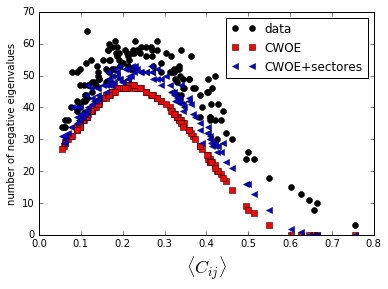

In [140]:
plt.plot(Cmean[::2],negativnum,"o",color="black", label="data")
plt.plot(Cmean[::2],WWnega,"rs",label="CWOE")
plt.plot(Cmean[::2],WWsec2nega,"b<",label="CWOE+sectores")
#plt.plot(Cmean,WWsecnega,"yo")
plt.ylabel("number of negative eigenvalues")
plt.xlabel(r"$ \langle C_{ij}\rangle$", size=18)
plt.legend()
plt.savefig('/cueva/Susana/SusanaDos/tesis_latex/negativosCmean.eps', format='eps', dpi=1000)

In [ ]:
plt.plot(valor2,WWnega,"o")

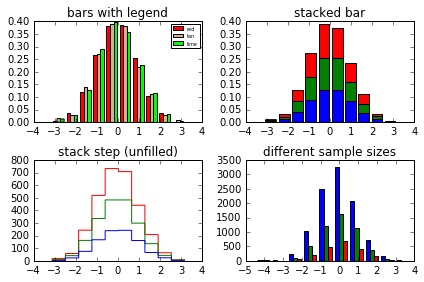

In [238]:
import numpy as np
import matplotlib.pyplot as plt

np.random.seed(0)

n_bins = 10
x = np.random.randn(1000, 3)

fig, axes = plt.subplots(nrows=2, ncols=2)
ax0, ax1, ax2, ax3 = axes.flatten()

colors = ['red', 'tan', 'lime']
ax0.hist(x, n_bins, normed=1, histtype='bar', color=colors, label=colors)
ax0.legend(prop={'size': 5})
ax0.set_title('bars with legend')

ax1.hist(x, n_bins, normed=1, histtype='bar', stacked=True)
ax1.set_title('stacked bar')

ax2.hist(x, n_bins, histtype='step', stacked=True, fill=False)
ax2.set_title('stack step (unfilled)')

# Make a multiple-histogram of data-sets with different length.
x_multi = [np.random.randn(n) for n in [10000, 5000, 2000]]
ax3.hist(x_multi, n_bins, histtype='bar')
ax3.set_title('different sample sizes')

fig.tight_layout()
#plt.show()

In [17]:
(1-.1)*(sqrt(293/44)-1)**2


2.2482432238132608

In [18]:
(sqrt(293*44))**-1

0.0088072404140473199